## **3. Extracting Embeddings for Different Model Types**

### **(A) BERT-like models (BERT, ELECTRA, SEC-BERT)**
- BERT-based models have a special **[CLS] token** at the beginning of each sequence.
- This token is often used as a **sentence representation**:

$$E = H[:, 0, :] \in \mathbb{R}^{B \times D}$$


where $( H[:, 0, :] )$ selects the first token embedding (the **[CLS] token**) for each batch instance.

**Why this works for drift detection?**
- The [CLS] embedding captures the **global context** of the sentence.
- If the dataset shifts (e.g., different topics, tone, vocabulary), this representation will change significantly.

---

### **(B) Decoder-only models (GPT-2, GPT-Neo, OPT, Mistral, Falcon, BLOOM)**
- These models **do not use a [CLS] token**.
- Instead, they rely on autoregressive prediction.
- The last token in the sequence often contains **the strongest contextual representation**:


$$E = H[:, -1, :] \in \mathbb{R}^{B \times D}$$

where $( H[:, -1, :])$ selects the embedding of the last token.

**Why this works for drift detection?**
- If text distributions change (e.g., from reviews to news articles), the **last token embeddings** will shift due to different sentence structures.

---

### **(C) Encoder-Decoder models (T5, MBART)**
- These models do **not have a [CLS] token**.
- Instead, they produce **token-wise hidden states** that are often pooled to obtain a fixed-size sentence representation.
- **Mean pooling** is used:


$$E = \frac{1}{L} \sum_{i=1}^{L} H[:, i, :]$$

where the embedding is the mean over all token embeddings.

**Why this works for drift detection?**
- Unlike single-token embeddings, mean pooling captures **context over the entire sentence**.
- It is more stable when sentence lengths and structures change.


In [21]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from sklearn.decomposition import PCA
from collections import defaultdict
import math


args = {
    "models": [
        "EleutherAI/gpt-neo-1.3B",  # Early open GPT model
        "mistralai/Mistral-7B-v0.1",  # Advanced Mixture-of-Experts model
        "facebook/opt-1.3b",  # Open-source GPT alternative
        "tiiuae/falcon-7b",  # High-efficiency causal model
        "bigscience/bloom-1b1",  # Multilingual GPT-style model
        "google/t5-small-ssm-nq",  # Small encoder-decoder model for classification/summarization
        "facebook/mbart-large-50",  # Multilingual seq2seq model
        "openai-community/gpt2",  # Classic GPT-2 model
        "distilbert-base-uncased",  # Small and efficient BERT model
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text",
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text",
        },
        {"name": "ag_news", "config": None, "split": "train", "text_column": "text"},
    ],
    "max_texts": 5,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "num_seeds": 1,
}
os.makedirs(args["output_dir"], exist_ok=True)


def extract_embeddings(model, tokenizer, texts, device):
    # Ensure padding token is set
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token  # Set pad token to EOS token

    encodings = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)

        # Handle different architectures
        if hasattr(outputs, "last_hidden_state"):
            hidden_states = outputs.last_hidden_state
            if model.config.model_type in [
                "gpt2",
                "gpt_neo",
                "opt",
                "mistral",
                "falcon",
                "bloom",
            ]:
                return (
                    hidden_states[:, -1, :].cpu().numpy()
                )  # Use last token embedding (decoder models)
            elif model.config.model_type in ["t5", "mbart"]:
                return (
                    hidden_states.mean(dim=1).cpu().numpy()
                )  # Mean pooling for encoder-decoder models
            elif (
                "bert" in model.config.model_type
                or "electra" in model.config.model_type
            ):
                return (
                    hidden_states[:, 0, :].cpu().numpy()
                )  # Use CLS token embedding for BERT-like models

        return None  # Handle unsupported cases


###############################################################################
# 1) Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]


def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts


###############################################################################
# 2) Vector/Feature-Space Distance Functions
###############################################################################
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))


def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))


def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)


def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))


def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)


DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),  # example p=3
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}


###############################################################################
# 3) EmbeddingTracker for Mahalanobis or the simpler distances
###############################################################################
class EmbeddingTracker:
    """
    A tracker that maintains:
    - An exponential-moving-average (EMA) of the embedding mean
    - An exponential-moving-average covariance (for Mahalanobis)
    - A selected distance metric: from one of the DISTANCE_FUNCTIONS
    """

    def __init__(self, embedding_dim, alpha=0.01, distance_name="mahalanobis"):
        self.alpha = alpha
        self.distance_name = distance_name

        # For all trackers, keep track of the mean.
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

        # Mahalanobis-specific
        self.cov = np.eye(embedding_dim)

    def update(self, embedding):
        """Update the running mean (and covariance, if Mahalanobis)."""
        if self.count == 0:
            self.mean = embedding
            if self.distance_name == "mahalanobis":
                self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

            if self.distance_name == "mahalanobis":
                diff = embedding - self.mean
                self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(
                    diff, diff
                )
        self.count += 1

    def compute_distance(self, embedding):
        """Compute distance between 'embedding' and the tracker's current mean."""
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            cov_inv = np.linalg.pinv(self.cov)
            return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)


def collect_data_single_seed(seed):
    """Run the entire process once for a given seed."""
    set_seed(seed)

    # Detect device
    device = torch.device(
        "mps"
        if torch.backends.mps.is_available()
        else "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = np.concatenate(
                [
                    extract_embeddings(model, tokenizer, b, device)
                    for b in batch_generator(baseline_texts, args["batch_size"])
                ],
                axis=0,
            )

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            key = (dataset_name, model_name)
            all_distance_names = ["mahalanobis"] + list(DISTANCE_FUNCTIONS.keys())

            for distance_name in all_distance_names:
                for drift_strength in args["drift_strengths"]:
                    drifted_texts = introduce_gradual_drift(
                        drift_texts, fraction_shuffle=drift_strength
                    )
                    test_texts = baseline_texts + drifted_texts

                    for use_pca in [False, True]:
                        embedding_dim = (
                            args["pca_components"]
                            if use_pca
                            else baseline_embs.shape[1]
                        )
                        tracker = EmbeddingTracker(
                            embedding_dim, alpha=0.01, distance_name=distance_name
                        )
                        distance_scores = []
                        time_overhead = []

                        # Initialize tracker with baseline distribution
                        for batch in batch_generator(
                            baseline_texts, args["batch_size"]
                        ):
                            emb = extract_embeddings(model, tokenizer, batch, device)
                            emb = pca.transform(emb) if use_pca else emb
                            tracker.update(emb.mean(axis=0))

                        start_time = time.time()
                        for batch in tqdm(
                            batch_generator(test_texts, args["batch_size"]), leave=False
                        ):
                            emb = extract_embeddings(model, tokenizer, batch, device)
                            emb = pca.transform(emb) if use_pca else emb
                            mean_emb = emb.mean(axis=0)
                            overhead_start = time.time()
                            dist = tracker.compute_distance(mean_emb)
                            overhead_end = time.time()
                            distance_scores.append(dist)
                            time_overhead.append(overhead_end - overhead_start)
                            tracker.update(mean_emb)
                        end_time = time.time()

                        final_dist = distance_scores[-1] if distance_scores else 0.0
                        total_time = end_time - start_time
                        avg_overhead = np.mean(time_overhead)

                        results[key].append(
                            {
                                "distance_name": distance_name,
                                "drift_strength": drift_strength,
                                "pca": use_pca,
                                "final_similarity": final_dist,
                                "time_taken": total_time,
                                "avg_overhead": avg_overhead,
                                "seed": seed,
                            }
                        )

    return results


def collect_data_multiple_seeds():
    all_results = defaultdict(list)

    for seed in range(args["num_seeds"]):
        seed_results = collect_data_single_seed(seed)
        for key, records in seed_results.items():
            all_results[key].extend(records)

    print("\nAll seeds complete!")
    return all_results


###############################################################################
# Run the Multi-Seed Experiments
###############################################################################
all_results = collect_data_multiple_seeds()

[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: EleutherAI/gpt-neo-1.3B ---


[Seed=0] --- Using Model: mistralai/Mistral-7B-v0.1 ---


Loading checkpoint shards: 100%|██████████| 2/2 [00:16<00:00,  8.44s/it]
                      


All seeds complete!


In [22]:
import pandas as pd

# Flatten all_results into a list of dictionaries
flattened_data = []
for (dataset_name, model_name), records in all_results.items():
    for r in records:
        r["Dataset"] = dataset_name
        r["Model"] = model_name
        flattened_data.append(r)

df = pd.DataFrame(flattened_data)

save_path = os.path.join(args["output_dir"], "all_results_vector_expand.csv")
df.to_csv(save_path, index=False)

print(f"Saved all_results to {save_path}")
df.head()

Saved all_results to results_multidataset/all_results_vector_expand.csv


,distance_name,drift_strength,pca,final_similarity,time_taken,avg_overhead,seed,Dataset,Model
0,mahalanobis,0.00,False,38.449458,1.745948,1.310617,0,yelp_review_full,EleutherAI/gpt-neo-1.3B
1,mahalanobis,0.00,True,6.147850,0.414959,0.000119,0,yelp_review_full,EleutherAI/gpt-neo-1.3B
2,mahalanobis,0.25,False,39.816229,1.813749,1.388893,0,yelp_review_full,EleutherAI/gpt-neo-1.3B
3,mahalanobis,0.25,True,3.545137,0.389570,0.000061,0,yelp_review_full,EleutherAI/gpt-neo-1.3B
4,mahalanobis,0.50,False,42.608968,1.703703,1.289797,0,yelp_review_full,EleutherAI/gpt-neo-1.3B


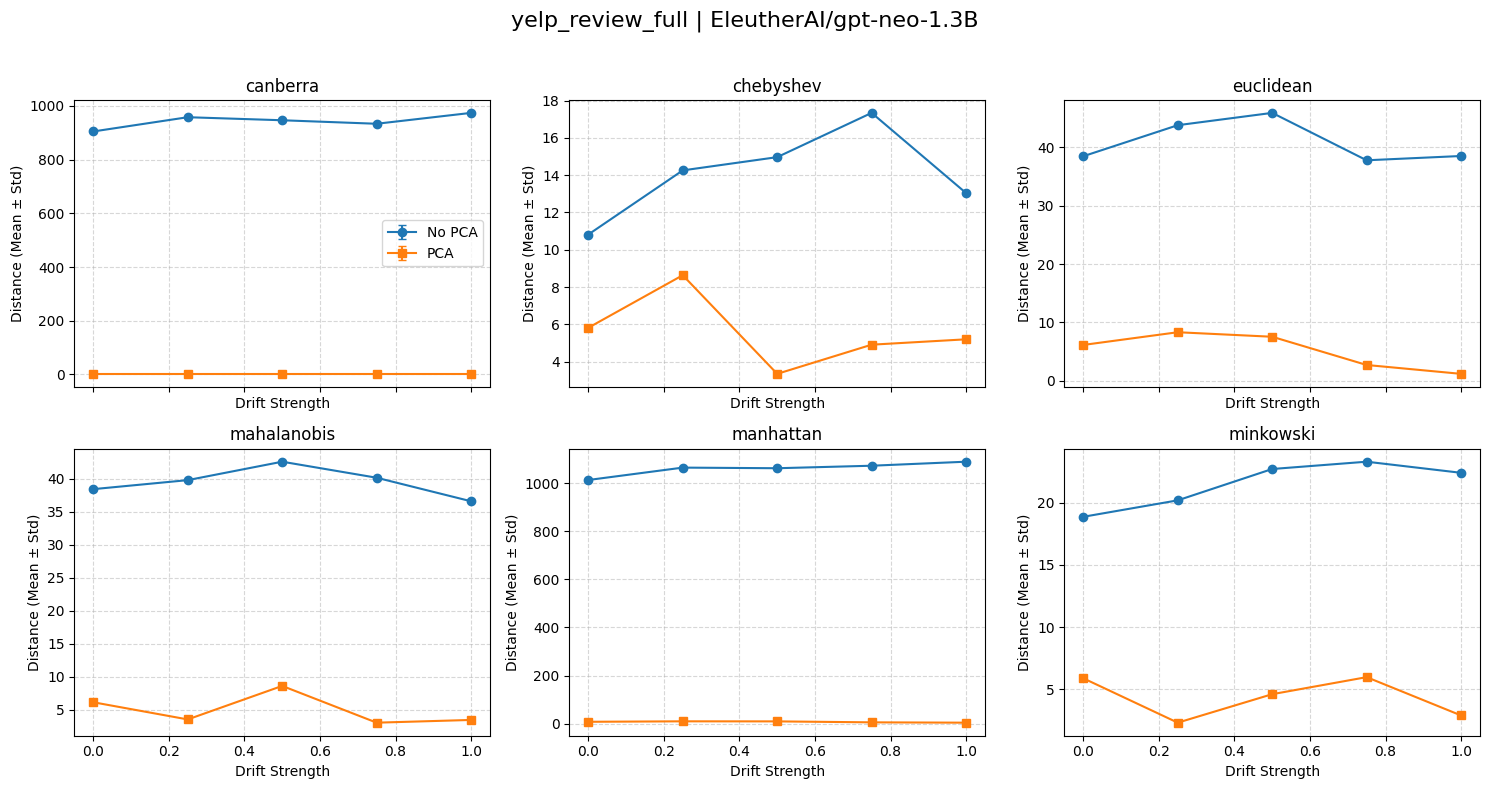

Saved figure: results_multidataset/yelp_review_full_EleutherAI_gpt-neo-1.3B_distances_errorbars.png


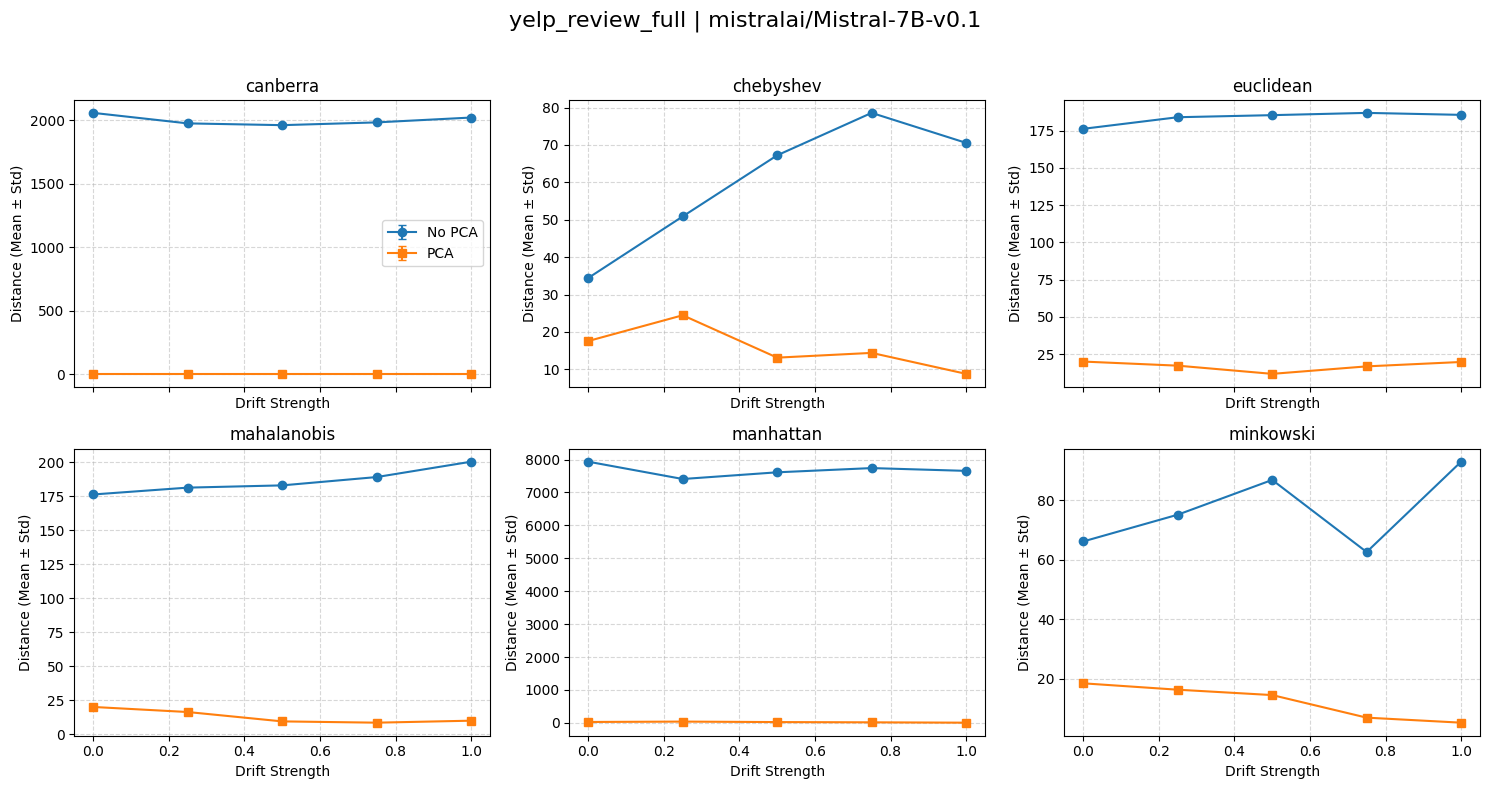

Saved figure: results_multidataset/yelp_review_full_mistralai_Mistral-7B-v0.1_distances_errorbars.png


In [23]:
###############################################################################
# 6) Plot with Error Bars
###############################################################################
def plot_distance_with_error_bars(all_results):
    """
    We aggregate across seeds: For each (dataset_name, model_name, distance_name, pca, drift_strength),
    compute the mean + std of final_distance across seeds.
    Then we plot error bars for each drift_strength for "No PCA" and "PCA" lines.
    """
    from collections import defaultdict

    # aggregated[(dataset_name, model_name, distance_name, pca, drift_strength)]
    # = list of final_distances for different seeds
    aggregator = defaultdict(list)

    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            dist_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            pca_flag = r["pca"]
            final_dist = r["final_similarity"]
            seed = r["seed"]

            key = (dataset_name, model_name, dist_name, pca_flag, drift_strength)
            aggregator[key].append(final_dist)

    # Now compute mean/std
    aggregated_data = []
    for key, dist_values in aggregator.items():
        dataset_name, model_name, dist_name, pca_flag, drift_strength = key
        mean_val = np.mean(dist_values)
        std_val = np.std(dist_values)
        aggregated_data.append(
            {
                "dataset_name": dataset_name,
                "model_name": model_name,
                "distance_name": dist_name,
                "pca": pca_flag,
                "drift_strength": drift_strength,
                "mean_val": mean_val,
                "std_val": std_val,
            }
        )

    # Now let's group by (dataset_name, model_name) for plotting
    from collections import defaultdict

    grouped = defaultdict(list)
    for row in aggregated_data:
        ds = row["dataset_name"]
        md = row["model_name"]
        grouped[(ds, md)].append(row)

    for (dataset_name, model_name), rows in grouped.items():
        # Gather all distance names
        dist_names = sorted(set(r["distance_name"] for r in rows))

        # Create subplots
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        fig, axs = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True
        )
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            # Filter for this dist_name, then separate PCA vs No PCA
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            no_pca = [r for r in dist_rows if r["pca"] == False]
            pca = [r for r in dist_rows if r["pca"] == True]

            no_pca_sorted = sorted(no_pca, key=lambda x: x["drift_strength"])
            pca_sorted = sorted(pca, key=lambda x: x["drift_strength"])

            x_no_pca = [r["drift_strength"] for r in no_pca_sorted]
            y_no_pca = [r["mean_val"] for r in no_pca_sorted]
            e_no_pca = [r["std_val"] for r in no_pca_sorted]

            x_pca = [r["drift_strength"] for r in pca_sorted]
            y_pca = [r["mean_val"] for r in pca_sorted]
            e_pca = [r["std_val"] for r in pca_sorted]

            # Plot error bars
            ax.errorbar(
                x_no_pca, y_no_pca, yerr=e_no_pca, fmt="-o", capsize=3, label="No PCA"
            )

            ax.errorbar(x_pca, y_pca, yerr=e_pca, fmt="-s", capsize=3, label="PCA")

            ax.set_title(dist_name)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance (Mean ± Std)")
            ax.grid(True, linestyle="--", alpha=0.5)
            if i == 0:
                ax.legend()

        # Hide leftover plots if any
        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved figure: {save_path}")


plot_distance_with_error_bars(all_results)

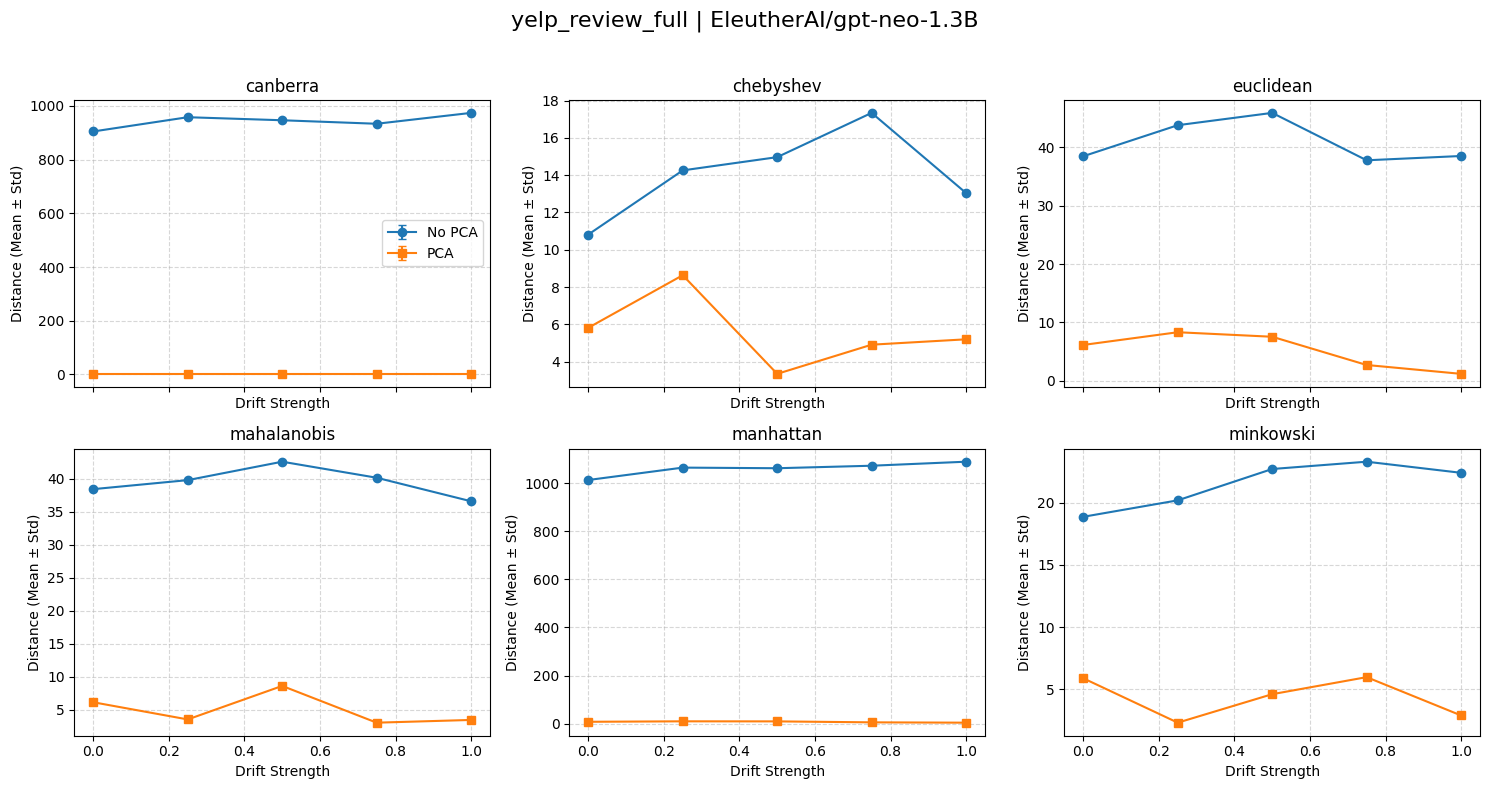

Saved figure: results_multidataset/yelp_review_full_EleutherAI_gpt-neo-1.3B_distances_errorbars.png


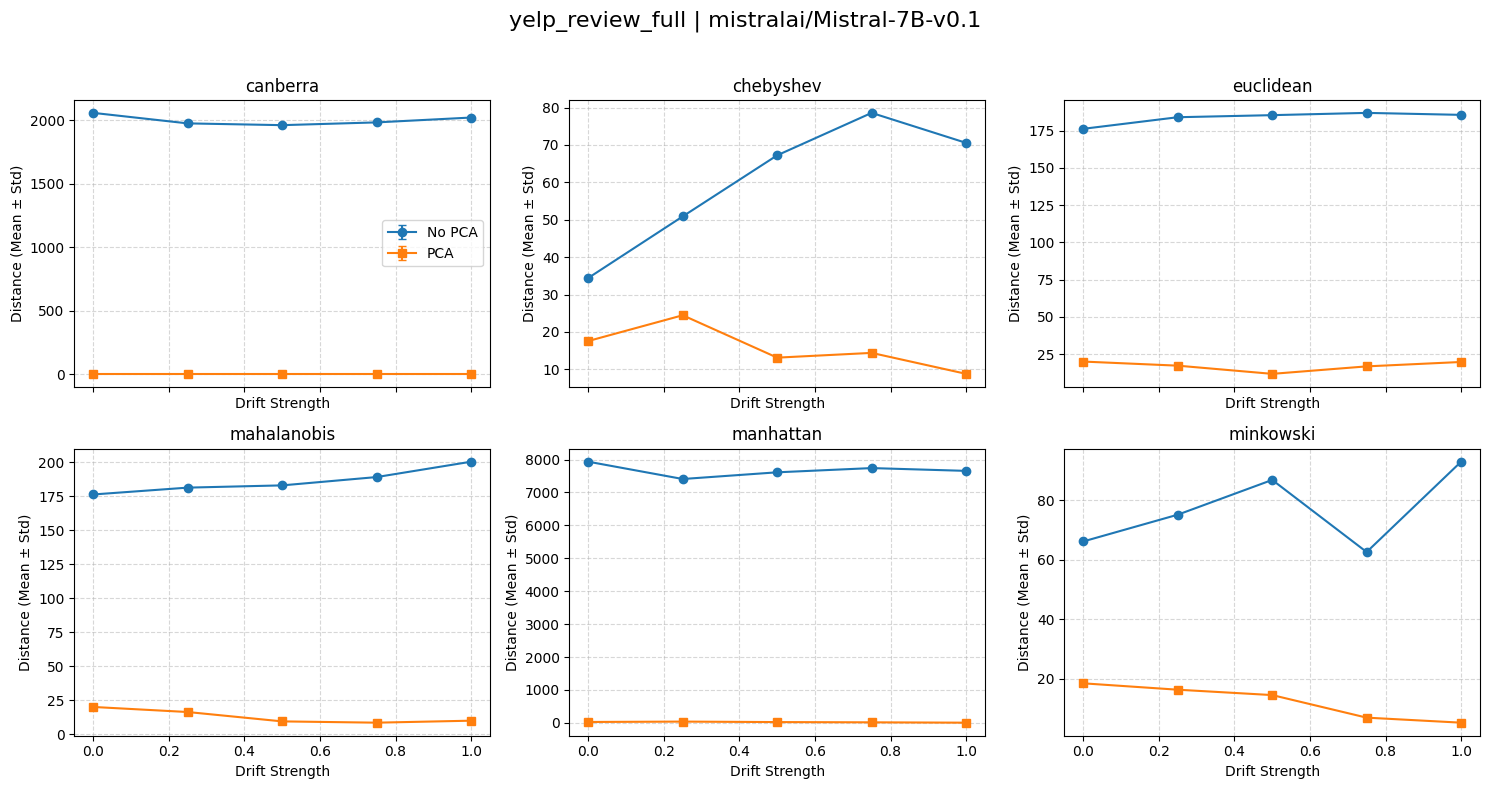

Saved figure: results_multidataset/yelp_review_full_mistralai_Mistral-7B-v0.1_distances_errorbars.png


In [24]:
def plot_overhead_bar_aggregated(summary_overhead):
    """
    Create a grouped bar chart of overhead, aggregated across all
    Datasets, Models, and Drift Strengths. Each bar represents
    (distance_name, pca_flag). The height is the *average* overhead,
    and the error bar shows the *standard deviation* of overhead.

    'summary_overhead' is a DataFrame with columns:
       [Dataset, Model, distance_name, pca, drift_strength,
        mean_overhead, std_overhead]
    """

    # 1) Collapse/aggregate across Dataset, Model, and Drift Strength
    #    to get a single average overhead (and std) per (distance_name, pca).
    grouped = (
        summary_overhead.groupby(["distance_name", "pca"])
        .agg(
            overhead_mean=("mean_overhead", "mean"),  # mean of means
            overhead_std=("mean_overhead", "std"),  # std of means
        )
        .reset_index()
    )

    # 2) Prepare data for a grouped bar chart.
    distance_names = grouped["distance_name"].unique()
    # Ensure consistent order
    distance_names.sort()
    pca_flags = [False, True]

    x_positions = np.arange(
        len(distance_names)
    )  # base x positions for each distance_name
    bar_width = 0.35

    plt.figure(figsize=(8, 5))

    # 3) Plot each pca_flag as a separate group
    for i, pca_val in enumerate(pca_flags):
        # Subset for pca_val
        sub = grouped[grouped["pca"] == pca_val].copy()
        # Match each distance_name in the sorted order
        # (so bars align correctly even if some are missing)
        sub = sub.set_index("distance_name").reindex(distance_names).reset_index()

        # x offset for this group
        offset = i * bar_width

        plt.bar(
            x_positions + offset,
            sub["overhead_mean"],
            yerr=sub["overhead_std"],
            width=bar_width,
            capsize=5,
            alpha=0.7,
            label=f"PCA={pca_val}",
        )

    # 4) Format the plot
    # Center the tick labels between the two grouped bars
    mid_points = x_positions + bar_width * (len(pca_flags) - 1) / 2
    plt.xticks(mid_points, distance_names, rotation=45, ha="right")
    plt.title(
        "Average Overhead by Distance Metric and PCA\n(Across All Datasets / Models / Drift Strengths)"
    )
    plt.xlabel("Distance Metric")
    plt.ylabel("Overhead (seconds)")
    plt.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


plot_distance_with_error_bars(all_results)

In [25]:
import pandas as pd
import os


def plot_overhead_per_model(summary_overhead, output_dir):
    """
    Generate a separate grouped bar chart of overhead for each model,
    comparing PCA vs. non-PCA cases using a log scale.
    """
    models = summary_overhead["Model"].unique()
    distance_names = summary_overhead["distance_name"].unique()
    distance_names.sort()
    pca_flags = [False, True]
    bar_width = 0.35

    for model in models:
        model_data = summary_overhead[summary_overhead["Model"] == model]
        x_positions = np.arange(len(distance_names))  # Base x positions

        plt.figure(figsize=(8, 5))

        for i, pca_val in enumerate(pca_flags):
            sub = model_data[model_data["pca"] == pca_val].copy()
            sub = (
                sub.drop_duplicates(subset=["distance_name"])
                .set_index("distance_name")
                .reindex(distance_names)
                .reset_index()
            )
            offset = i * bar_width

            plt.bar(
                x_positions + offset,
                sub["mean_overhead"],
                yerr=sub["std_overhead"],
                width=bar_width,
                capsize=5,
                alpha=0.7,
                label=f"PCA={pca_val}",
            )

        # Apply log scale
        plt.yscale("log")  # <-- LOG SCALE applied

        # Center the tick labels between the two grouped bars
        mid_points = x_positions + bar_width * (len(pca_flags) - 1) / 2
        plt.xticks(mid_points, distance_names, rotation=45, ha="right")
        plt.title(f"Overhead Comparison for Model: {model} (Log Scale)")
        plt.xlabel("Distance Metric")
        plt.ylabel("Overhead (seconds, log scale)")
        plt.legend()
        plt.tight_layout()
        plt.grid(axis="y", linestyle="--", alpha=0.5)

        output_path = os.path.join(
            output_dir, f"overhead_{model.replace('/', '_')}.png"
        )
        plt.savefig(output_path)
        print(f"Saved plot to: {output_path}")
        plt.show()


# Load data from CSV
results_path = os.path.join("results_multidataset", "all_results_vector_space.csv")
df = pd.read_csv(results_path)

# Compute summary statistics
summary_overhead = (
    df.groupby(["Dataset", "Model", "distance_name", "pca", "drift_strength"])
    .agg(mean_overhead=("avg_overhead", "mean"), std_overhead=("avg_overhead", "std"))
    .reset_index()
)

# Output directory for saving plots
output_dir = "results_multidataset/overhead_plots"
os.makedirs(output_dir, exist_ok=True)

# Plot overhead per model and save results
plot_overhead_per_model(summary_overhead, output_dir)

ValueError: cannot reindex on an axis with duplicate labels

<Figure size 800x500 with 0 Axes>